In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('USW00014607.csv')

C:\Users\steph\AppData\Local\Temp\ipykernel_27768\2787897989.py:1: DtypeWarning: Columns (17,19,21,23,25,27,29,31,33,35,37,39,41,43,45,47,49,51,53,55,57,59,61,63,65,67,69,71,73,75,77,79,81,83,85,87,89,91,93,95,97,101,107,109,111,115,117,119,121,123,125,127,129,131,133,135,137,139,141,143) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('USW00014607.csv')


In [3]:
df

,STATION,DATE,LATITUDE,LONGITUDE,ELEVATION,NAME,PRCP,PRCP_ATTRIBUTES,SNOW,SNOW_ATTRIBUTES,...,WT19,WT19_ATTRIBUTES,WT21,WT21_ATTRIBUTES,WT22,WT22_ATTRIBUTES,WV03,WV03_ATTRIBUTES,WV20,WV20_ATTRIBUTES
0,USW00014607,1939-01-16,46.87049,-68.01723,188.6,"CARIBOU WEATHER FORECAST OFFICE, ME US",0.0,",,0,",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,USW00014607,1939-01-17,46.87049,-68.01723,188.6,"CARIBOU WEATHER FORECAST OFFICE, ME US",0.0,"T,,0,",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,USW00014607,1939-01-18,46.87049,-68.01723,188.6,"CARIBOU WEATHER FORECAST OFFICE, ME US",0.0,"T,,0,",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,USW00014607,1939-01-19,46.87049,-68.01723,188.6,"CARIBOU WEATHER FORECAST OFFICE, ME US",0.0,",,0,",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,USW00014607,1939-01-20,46.87049,-68.01723,188.6,"CARIBOU WEATHER FORECAST OFFICE, ME US",0.0,"T,,0,",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31467,USW00014607,2025-05-07,46.87049,-68.01723,188.6,"CARIBOU WEATHER FORECAST OFFICE, ME US",8.0,",,W,2400",0.0,",,W,2400",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31468,USW00014607,2025-05-08,46.87049,-68.01723,188.6,"CARIBOU WEATHER FORECAST OFFICE, ME US",5.0,",,W,2400",0.0,",,W,2400",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31469,USW00014607,2025-05-09,46.87049,-68.01723,188.6,"CARIBOU WEATHER FORECAST OFFICE, ME US",0.0,",,W,2400",0.0,",,W,2400",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31470,USW00014607,2025-05-10,46.87049,-68.01723,188.6,"CARIBOU WEATHER FORECAST OFFICE, ME US",114.0,",,W,2400",0.0,",,D,2400",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31472 entries, 0 to 31471
Columns: 144 entries, STATION to WV20_ATTRIBUTES
dtypes: float64(72), object(72)
memory usage: 34.6+ MB


In [5]:
df.head()


,STATION,DATE,LATITUDE,LONGITUDE,ELEVATION,NAME,PRCP,PRCP_ATTRIBUTES,SNOW,SNOW_ATTRIBUTES,...,WT19,WT19_ATTRIBUTES,WT21,WT21_ATTRIBUTES,WT22,WT22_ATTRIBUTES,WV03,WV03_ATTRIBUTES,WV20,WV20_ATTRIBUTES
0,USW00014607,1939-01-16,46.87049,-68.01723,188.6,"CARIBOU WEATHER FORECAST OFFICE, ME US",0.0,",,0,",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,USW00014607,1939-01-17,46.87049,-68.01723,188.6,"CARIBOU WEATHER FORECAST OFFICE, ME US",0.0,"T,,0,",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,USW00014607,1939-01-18,46.87049,-68.01723,188.6,"CARIBOU WEATHER FORECAST OFFICE, ME US",0.0,"T,,0,",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,USW00014607,1939-01-19,46.87049,-68.01723,188.6,"CARIBOU WEATHER FORECAST OFFICE, ME US",0.0,",,0,",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,USW00014607,1939-01-20,46.87049,-68.01723,188.6,"CARIBOU WEATHER FORECAST OFFICE, ME US",0.0,"T,,0,",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Étape 1 : Supprimer les colonnes avec plus de 99% de valeurs manquantes
threshold = 0.99
missing_ratio = df.isna().mean()
cols_to_drop_na = missing_ratio[missing_ratio > threshold].index.tolist()


In [7]:
# Étape 2 : Supprimer les colonnes *_ATTRIBUTES car souvent peu utiles
cols_to_drop_attr = [col for col in df.columns if "ATTRIBUTES" in col]


In [8]:
# Combiner les colonnes à supprimer
cols_to_drop = list(set(cols_to_drop_na + cols_to_drop_attr))


In [9]:
# Nettoyer le DataFrame
df_cleaned = df.drop(columns=cols_to_drop)


In [10]:
# Vérifier s'il y a des doublons
num_duplicates = df_cleaned.duplicated().sum()


In [11]:
# Vérifier la présence de la colonne cible "TMAX"
has_tmax = "TMAX" in df_cleaned.columns


In [12]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31472 entries, 0 to 31471
Data columns (total 55 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   STATION    31472 non-null  object 
 1   DATE       31472 non-null  object 
 2   LATITUDE   31472 non-null  float64
 3   LONGITUDE  31472 non-null  float64
 4   ELEVATION  31472 non-null  float64
 5   NAME       31472 non-null  object 
 6   PRCP       31470 non-null  float64
 7   SNOW       31118 non-null  float64
 8   SNWD       31202 non-null  float64
 9   TMAX       31468 non-null  float64
 10  TMIN       31469 non-null  float64
 11  ACSH       10920 non-null  float64
 12  ADPT       6869 non-null   float64
 13  ASLP       6844 non-null   float64
 14  ASTP       6844 non-null   float64
 15  AWBT       6869 non-null   float64
 16  AWND       15100 non-null  float64
 17  EVAP       7598 non-null   float64
 18  FMTM       8155 non-null   float64
 19  MNPN       7680 non-null   float64
 20  MXPN  

In [13]:
# Calculer le pourcentage de valeurs manquantes pour chaque colonne
missing_percentage = df_cleaned.isna().mean().sort_values(ascending=False) * 100


In [14]:

# Afficher uniquement les colonnes ayant plus de 10% de valeurs manquantes
missing_over_10 = missing_percentage[missing_percentage > 10]


In [15]:
missing_over_10

WT22    98.760803
WT05    98.630529
WT19    98.570158
WT04    98.300076
WT09    98.017285
WDFG    97.985511
WT06    97.893366
WT14    97.785333
WSFG    97.766268
WT03    96.237926
TSUN    96.206151
WT02    96.012328
WT08    93.559354
WDF1    92.196238
WSF1    91.783172
WT13    90.543976
TAVG    89.606634
WT18    84.417895
SX52    84.205008
SN52    84.189120
PGTM    82.412938
ASTP    78.253686
ASLP    78.253686
AWBT    78.174250
ADPT    78.174250
RHMN    78.152008
RHMX    78.152008
RHAV    78.152008
WT16    77.796136
EVAP    75.857905
WDMV    75.689502
MNPN    75.597356
MXPN    75.492501
SX02    74.850661
SN02    74.847483
FMTM    74.088078
WT01    71.094942
WDF5    66.770463
WSF5    66.770463
WSF2    66.519446
WDF2    66.519446
ACSH    65.302491
WESD    63.243518
AWND    52.020844
dtype: float64

In [16]:
# Définir le seuil de suppression à 80%
drop_threshold = 0.80

In [17]:
# Identifier les colonnes à supprimer
cols_to_drop_high_nan = missing_percentage[missing_percentage > drop_threshold * 100].index.tolist()


In [18]:
# Appliquer la suppression sur df_cleaned
df_cleaned_reduced = df_cleaned.drop(columns=cols_to_drop_high_nan)


In [19]:
# Vérifier la nouvelle forme du DataFrame et le nombre de colonnes supprimées
new_shape = df_cleaned_reduced.shape
num_dropped = len(cols_to_drop_high_nan)
new_shape, num_dropped

((31472, 34), 21)

In [20]:
df_cleaned_reduced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31472 entries, 0 to 31471
Data columns (total 34 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   STATION    31472 non-null  object 
 1   DATE       31472 non-null  object 
 2   LATITUDE   31472 non-null  float64
 3   LONGITUDE  31472 non-null  float64
 4   ELEVATION  31472 non-null  float64
 5   NAME       31472 non-null  object 
 6   PRCP       31470 non-null  float64
 7   SNOW       31118 non-null  float64
 8   SNWD       31202 non-null  float64
 9   TMAX       31468 non-null  float64
 10  TMIN       31469 non-null  float64
 11  ACSH       10920 non-null  float64
 12  ADPT       6869 non-null   float64
 13  ASLP       6844 non-null   float64
 14  ASTP       6844 non-null   float64
 15  AWBT       6869 non-null   float64
 16  AWND       15100 non-null  float64
 17  EVAP       7598 non-null   float64
 18  FMTM       8155 non-null   float64
 19  MNPN       7680 non-null   float64
 20  MXPN  

In [21]:
# Recalculer le pourcentage de NaN dans le DataFrame réduit
missing_remaining = df_cleaned_reduced.isna().mean().sort_values(ascending=False) * 100


In [22]:
# Afficher uniquement les colonnes ayant encore des NaN
missing_remaining = missing_remaining[missing_remaining > 0]


In [23]:
missing_remaining.reset_index().rename(columns={'index': 'Colonne', 0: 'Pourcentage de NaN'})


,Colonne,Pourcentage de NaN
0,ASTP,78.253686
1,ASLP,78.253686
2,ADPT,78.174250
3,AWBT,78.174250
4,RHMX,78.152008
5,RHMN,78.152008
6,RHAV,78.152008
7,WT16,77.796136
8,EVAP,75.857905
9,WDMV,75.689502


In [24]:
# Supprimer les colonnes restantes avec plus de 70% de NaN, comme discuté
high_nan_columns = df_cleaned_reduced.columns[df_cleaned_reduced.isna().mean() > 0.70]
df_final = df_cleaned_reduced.drop(columns=high_nan_columns)


In [25]:
# Vérifier les dimensions finales
final_shape = df_final.shape
columns_removed = list(high_nan_columns)

In [26]:
final_shape, columns_removed

((31472, 18),
 ['ADPT',
  'ASLP',
  'ASTP',
  'AWBT',
  'EVAP',
  'FMTM',
  'MNPN',
  'MXPN',
  'RHAV',
  'RHMN',
  'RHMX',
  'WDMV',
  'SN02',
  'SX02',
  'WT01',
  'WT16'])

In [27]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31472 entries, 0 to 31471
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   STATION    31472 non-null  object 
 1   DATE       31472 non-null  object 
 2   LATITUDE   31472 non-null  float64
 3   LONGITUDE  31472 non-null  float64
 4   ELEVATION  31472 non-null  float64
 5   NAME       31472 non-null  object 
 6   PRCP       31470 non-null  float64
 7   SNOW       31118 non-null  float64
 8   SNWD       31202 non-null  float64
 9   TMAX       31468 non-null  float64
 10  TMIN       31469 non-null  float64
 11  ACSH       10920 non-null  float64
 12  AWND       15100 non-null  float64
 13  WDF2       10537 non-null  float64
 14  WDF5       10458 non-null  float64
 15  WESD       11568 non-null  float64
 16  WSF2       10537 non-null  float64
 17  WSF5       10458 non-null  float64
dtypes: float64(15), object(3)
memory usage: 4.3+ MB


In [28]:
df_final

,STATION,DATE,LATITUDE,LONGITUDE,ELEVATION,NAME,PRCP,SNOW,SNWD,TMAX,TMIN,ACSH,AWND,WDF2,WDF5,WESD,WSF2,WSF5
0,USW00014607,1939-01-16,46.87049,-68.01723,188.6,"CARIBOU WEATHER FORECAST OFFICE, ME US",0.0,NaN,NaN,-72.0,-206.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,USW00014607,1939-01-17,46.87049,-68.01723,188.6,"CARIBOU WEATHER FORECAST OFFICE, ME US",0.0,NaN,NaN,-39.0,-172.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,USW00014607,1939-01-18,46.87049,-68.01723,188.6,"CARIBOU WEATHER FORECAST OFFICE, ME US",0.0,NaN,NaN,-139.0,-244.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,USW00014607,1939-01-19,46.87049,-68.01723,188.6,"CARIBOU WEATHER FORECAST OFFICE, ME US",0.0,NaN,NaN,-122.0,-244.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,USW00014607,1939-01-20,46.87049,-68.01723,188.6,"CARIBOU WEATHER FORECAST OFFICE, ME US",0.0,NaN,NaN,-111.0,-206.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31467,USW00014607,2025-05-07,46.87049,-68.01723,188.6,"CARIBOU WEATHER FORECAST OFFICE, ME US",8.0,0.0,0.0,189.0,111.0,NaN,38.0,180.0,170.0,NaN,89.0,116.0
31468,USW00014607,2025-05-08,46.87049,-68.01723,188.6,"CARIBOU WEATHER FORECAST OFFICE, ME US",5.0,0.0,0.0,133.0,50.0,NaN,49.0,360.0,350.0,NaN,94.0,130.0
31469,USW00014607,2025-05-09,46.87049,-68.01723,188.6,"CARIBOU WEATHER FORECAST OFFICE, ME US",0.0,0.0,0.0,172.0,39.0,NaN,32.0,160.0,40.0,NaN,54.0,76.0
31470,USW00014607,2025-05-10,46.87049,-68.01723,188.6,"CARIBOU WEATHER FORECAST OFFICE, ME US",114.0,0.0,0.0,89.0,56.0,NaN,40.0,10.0,340.0,NaN,81.0,125.0


In [29]:
# Supprimer les colonnes inutiles identifiées : STATION, NAME, LATITUDE, LONGITUDE, ELEVATION
columns_to_remove = ['STATION', 'NAME', 'LATITUDE', 'LONGITUDE', 'ELEVATION']
df_final_cleaned = df_final.drop(columns=columns_to_remove)


In [30]:
df_final_cleaned

,DATE,PRCP,SNOW,SNWD,TMAX,TMIN,ACSH,AWND,WDF2,WDF5,WESD,WSF2,WSF5
0,1939-01-16,0.0,NaN,NaN,-72.0,-206.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1939-01-17,0.0,NaN,NaN,-39.0,-172.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1939-01-18,0.0,NaN,NaN,-139.0,-244.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1939-01-19,0.0,NaN,NaN,-122.0,-244.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1939-01-20,0.0,NaN,NaN,-111.0,-206.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
31467,2025-05-07,8.0,0.0,0.0,189.0,111.0,NaN,38.0,180.0,170.0,NaN,89.0,116.0
31468,2025-05-08,5.0,0.0,0.0,133.0,50.0,NaN,49.0,360.0,350.0,NaN,94.0,130.0
31469,2025-05-09,0.0,0.0,0.0,172.0,39.0,NaN,32.0,160.0,40.0,NaN,54.0,76.0
31470,2025-05-10,114.0,0.0,0.0,89.0,56.0,NaN,40.0,10.0,340.0,NaN,81.0,125.0


In [31]:
nan_summary = df_final_cleaned.isna().mean().sort_values(ascending=False) * 100


In [32]:
# Supprimer les colonnes avec plus de 50% de valeurs manquantes
columns_to_drop_over_50 = nan_summary[nan_summary > 50].index.tolist()
df_final_ready = df_final_cleaned.drop(columns=columns_to_drop_over_50)


In [33]:
df_final_ready

,DATE,PRCP,SNOW,SNWD,TMAX,TMIN
0,1939-01-16,0.0,NaN,NaN,-72.0,-206.0
1,1939-01-17,0.0,NaN,NaN,-39.0,-172.0
2,1939-01-18,0.0,NaN,NaN,-139.0,-244.0
3,1939-01-19,0.0,NaN,NaN,-122.0,-244.0
4,1939-01-20,0.0,NaN,NaN,-111.0,-206.0
...,...,...,...,...,...,...
31467,2025-05-07,8.0,0.0,0.0,189.0,111.0
31468,2025-05-08,5.0,0.0,0.0,133.0,50.0
31469,2025-05-09,0.0,0.0,0.0,172.0,39.0
31470,2025-05-10,114.0,0.0,0.0,89.0,56.0


In [34]:
# Convertir la colonne DATE en format datetime
df_final_ready['DATE'] = pd.to_datetime(df_final_ready['DATE'])


In [35]:
# Extraire des caractéristiques temporelles
df_final_ready['YEAR'] = df_final_ready['DATE'].dt.year
df_final_ready['MONTH'] = df_final_ready['DATE'].dt.month
df_final_ready['DAY'] = df_final_ready['DATE'].dt.day
df_final_ready['DAYOFYEAR'] = df_final_ready['DATE'].dt.dayofyear
df_final_ready['WEEKDAY'] = df_final_ready['DATE'].dt.weekday
df_final_ready['SEASON'] = df_final_ready['DATE'].dt.month % 12 // 3 + 1  # 1: Winter, 2: Spring, 3: Summer, 4: Fall


In [36]:
# Supprimer la colonne DATE (on a extrait les infos utiles)
df_final_ready = df_final_ready.drop(columns=['DATE'])


In [37]:
# Afficher les premières lignes pour vérification
df_final_ready.head()

,PRCP,SNOW,SNWD,TMAX,TMIN,YEAR,MONTH,DAY,DAYOFYEAR,WEEKDAY,SEASON
0,0.0,NaN,NaN,-72.0,-206.0,1939,1,16,16,0,1
1,0.0,NaN,NaN,-39.0,-172.0,1939,1,17,17,1,1
2,0.0,NaN,NaN,-139.0,-244.0,1939,1,18,18,2,1
3,0.0,NaN,NaN,-122.0,-244.0,1939,1,19,19,3,1
4,0.0,NaN,NaN,-111.0,-206.0,1939,1,20,20,4,1


In [38]:
# Ré-imputation pour s'assurer qu'il n'y ait plus de NaN dans SNOW et SNWD
df_final_ready['SNOW'] = df_final_ready['SNOW'].fillna(df_final_ready['SNOW'].median())
df_final_ready['SNWD'] = df_final_ready['SNWD'].fillna(df_final_ready['SNWD'].median())


In [39]:
# Vérification que les colonnes ne contiennent plus de NaN
nan_check = df_final_ready[['SNOW', 'SNWD']].isna().sum()


In [40]:
nan_check

SNOW    0
SNWD    0
dtype: int64

In [41]:
# Analyse des corrélations avec TMAX
correlation_with_tmax = df_final_ready.corr(numeric_only=True)['TMAX'].sort_values(ascending=False)


In [42]:
correlation_with_tmax

TMAX         1.000000
TMIN         0.930167
SEASON       0.575244
MONTH        0.247116
DAYOFYEAR    0.244506
PRCP         0.050922
YEAR         0.039566
DAY          0.013753
WEEKDAY      0.001012
SNOW        -0.247928
SNWD        -0.596124
Name: TMAX, dtype: float64

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
# Configurer le style des graphiques
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

C:\Users\steph\AppData\Local\Temp\ipykernel_27768\2430554421.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr.values, y=corr.index, palette='coolwarm')


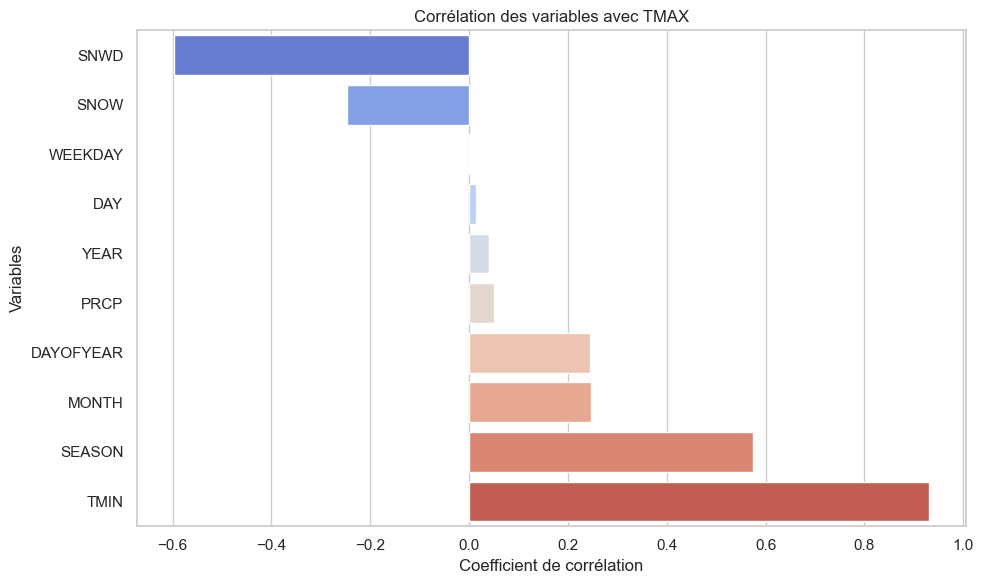

In [45]:
# 1. Barplot des corrélations avec TMAX (hors TMAX lui-même)
corr = df_final_ready.corr(numeric_only=True)['TMAX'].drop('TMAX').sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=corr.values, y=corr.index, palette='coolwarm')
plt.title('Corrélation des variables avec TMAX')
plt.xlabel('Coefficient de corrélation')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()


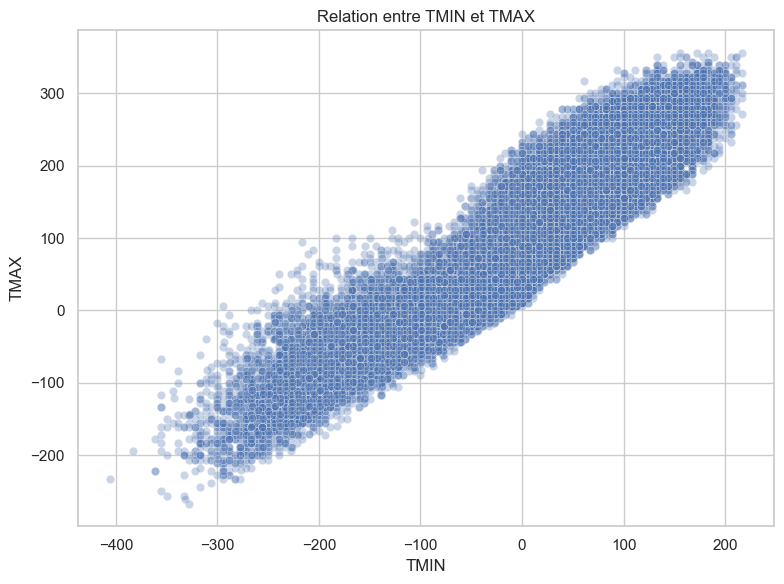

In [46]:
# 2. Scatterplot entre TMAX et TMIN
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_final_ready, x='TMIN', y='TMAX', alpha=0.3)
plt.title('Relation entre TMIN et TMAX')
plt.xlabel('TMIN')
plt.ylabel('TMAX')
plt.tight_layout()
plt.show()

C:\Users\steph\AppData\Local\Temp\ipykernel_27768\135254356.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final_ready, x='SEASON', y='TMAX', palette='Set2')


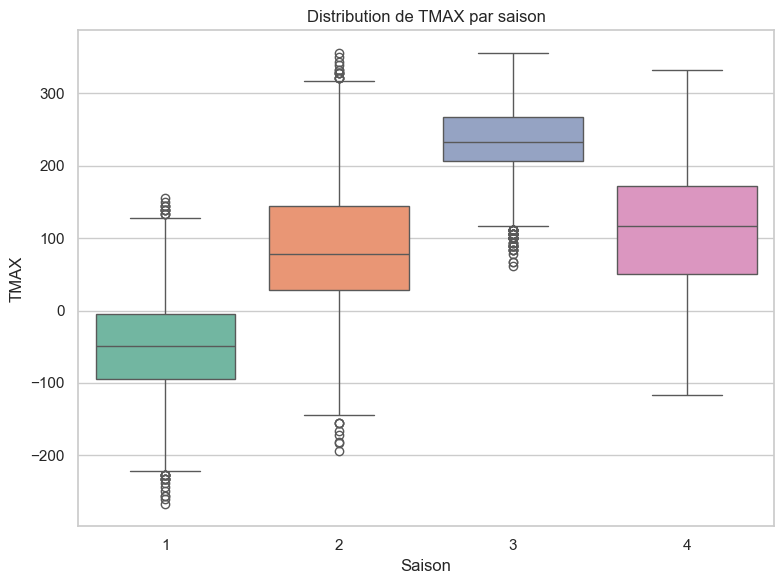

In [47]:
# 3. Boxplot de TMAX par saison
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_final_ready, x='SEASON', y='TMAX', palette='Set2')
plt.title('Distribution de TMAX par saison')
plt.xlabel('Saison')
plt.ylabel('TMAX')
plt.tight_layout()
plt.show()

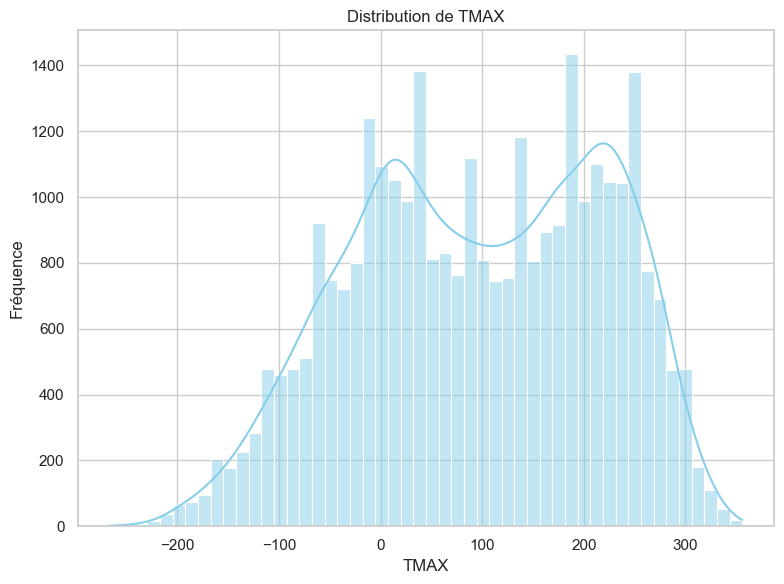

In [48]:
# 4. Distribution de TMAX
plt.figure(figsize=(8, 6))
sns.histplot(df_final_ready['TMAX'], kde=True, bins=50, color='skyblue')
plt.title('Distribution de TMAX')
plt.xlabel('TMAX')
plt.ylabel('Fréquence')
plt.tight_layout()
plt.show()

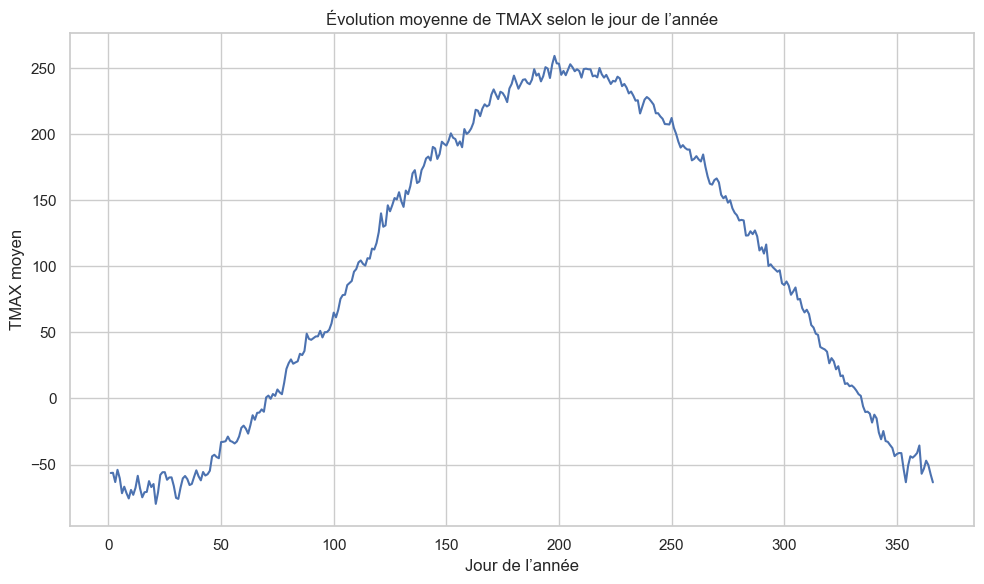

In [49]:

# 5. TMAX au fil des jours de l’année (moyenne)
plt.figure(figsize=(10, 6))
avg_tmax_by_dayofyear = df_final_ready.groupby('DAYOFYEAR')['TMAX'].mean()
sns.lineplot(x=avg_tmax_by_dayofyear.index, y=avg_tmax_by_dayofyear.values)
plt.title('Évolution moyenne de TMAX selon le jour de l’année')
plt.xlabel('Jour de l’année')
plt.ylabel('TMAX moyen')
plt.tight_layout()
plt.show()

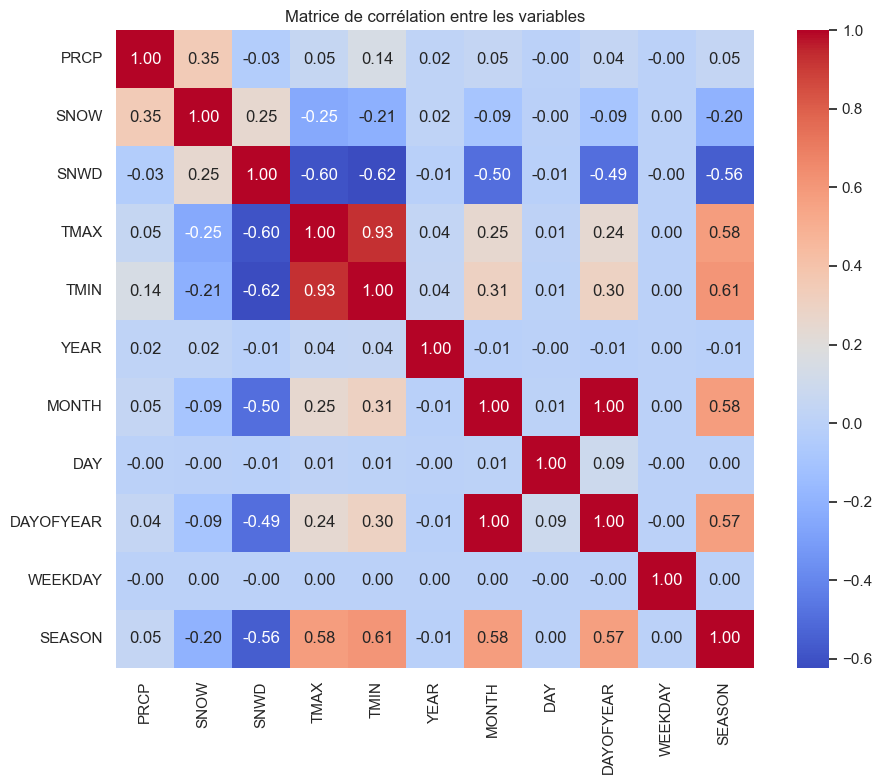

In [50]:
# 6. Heatmap de corrélation globale
plt.figure(figsize=(10, 8))
sns.heatmap(df_final_ready.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Matrice de corrélation entre les variables')
plt.tight_layout()
plt.show()

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [52]:

# 1. Supprimer les lignes où TMAX est manquant
df_model = df_final_ready.dropna(subset=['TMAX'])

In [53]:
df_model

,PRCP,SNOW,SNWD,TMAX,TMIN,YEAR,MONTH,DAY,DAYOFYEAR,WEEKDAY,SEASON
0,0.0,0.0,0.0,-72.0,-206.0,1939,1,16,16,0,1
1,0.0,0.0,0.0,-39.0,-172.0,1939,1,17,17,1,1
2,0.0,0.0,0.0,-139.0,-244.0,1939,1,18,18,2,1
3,0.0,0.0,0.0,-122.0,-244.0,1939,1,19,19,3,1
4,0.0,0.0,0.0,-111.0,-206.0,1939,1,20,20,4,1
...,...,...,...,...,...,...,...,...,...,...,...
31466,0.0,0.0,0.0,189.0,44.0,2025,5,6,126,1,2
31467,8.0,0.0,0.0,189.0,111.0,2025,5,7,127,2,2
31468,5.0,0.0,0.0,133.0,50.0,2025,5,8,128,3,2
31469,0.0,0.0,0.0,172.0,39.0,2025,5,9,129,4,2


In [54]:
# Définir X (features) et y (cible)
features = ['TMIN', 'SNOW', 'SNWD', 'MONTH', 'DAYOFYEAR', 'SEASON']
X = df_model[features]
y = df_model['TMAX']

In [55]:
# Étape 1 : Imputation des NaN par la médiane
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

In [56]:
from sklearn.preprocessing import MinMaxScaler  

scaler = MinMaxScaler()  
X_scaler = scaler.fit_transform(X_imputed) 
X_scaler

array([[0.32102729, 0.        , 0.        , 0.        , 0.04109589,
        0.        ],
       [0.37560193, 0.        , 0.        , 0.        , 0.04383562,
        0.        ],
       [0.2600321 , 0.        , 0.        , 0.        , 0.04657534,
        0.        ],
       ...,
       [0.73194222, 0.        , 0.        , 0.36363636, 0.34794521,
        0.33333333],
       [0.71428571, 0.        , 0.        , 0.36363636, 0.35068493,
        0.33333333],
       [0.74157303, 0.        , 0.        , 0.36363636, 0.35342466,
        0.33333333]])

In [57]:
# Étape 3 : Split train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaler, y, test_size=0.2, random_state=42)


In [58]:
# Étape 4 : Régression linéaire
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [59]:
# 7. Évaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("✅ Régression terminée")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.2f}")

✅ Régression terminée
RMSE : 43.72
MAE  : 35.85
R²   : 0.88


In [60]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [61]:
# 🌳 6. Modèle Arbre de Décision
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)
tree_preds = tree_model.predict(X_test)

In [62]:
# 🌲 7. Modèle Random Forest
forest_model = RandomForestRegressor(n_estimators=200, random_state=42)
forest_model.fit(X_train, y_train)
forest_preds = forest_model.predict(X_test)

In [63]:
def eval_model(name, y_true, y_pred):
    print(f"\n {name}")
    print(f"  RMSE : {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")
    print(f"  MAE  : {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"  R²   : {r2_score(y_true, y_pred):.2f}")

In [64]:
eval_model("Arbre de Décision", y_test, tree_preds)


 Arbre de Décision
  RMSE : 47.62
  MAE  : 37.33
  R²   : 0.86


In [65]:
eval_model("Random Forest", y_test, forest_preds)


 Random Forest
  RMSE : 40.66
  MAE  : 32.09
  R²   : 0.89


C:\Users\steph\AppData\Local\Temp\ipykernel_27768\2760880795.py:8: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\steph\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


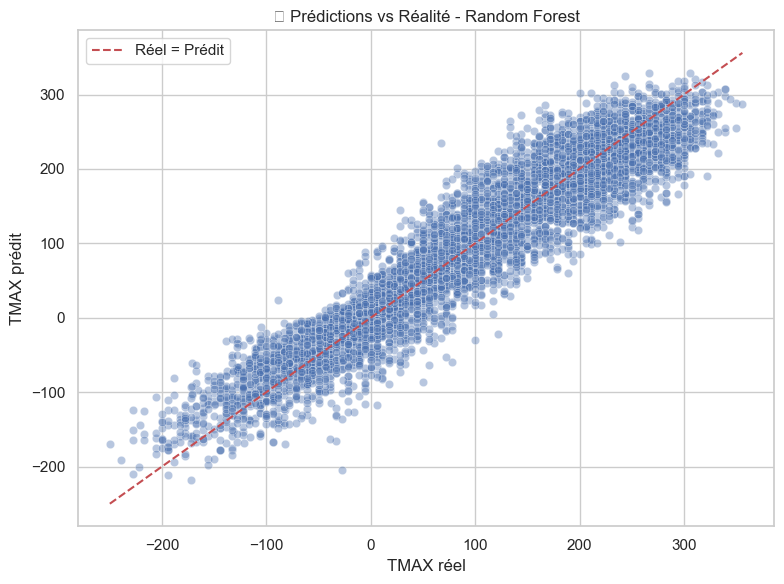

In [66]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=forest_preds, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', label="Réel = Prédit")
plt.xlabel("TMAX réel")
plt.ylabel("TMAX prédit")
plt.title("📈 Prédictions vs Réalité - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

In [67]:
# Exemple personnalisé : "Un jour chaud en été"
custom_input = {
    "TMIN": -244,        # 18.0°C
    "SNOW": 0,          # Pas de neige
    "SNWD": 0,          # Pas de neige au sol
    "MONTH": 1,         # Juillet
    "DAYOFYEAR": 18,   # Vers la fin juillet
    "SEASON": 1         # Été
}

In [68]:
# 3. Organiser les données dans le bon ordre
input_array = np.array([[custom_input[feature] for feature in ['TMIN', 'SNOW', 'SNWD', 'MONTH', 'DAYOFYEAR', 'SEASON']]])

# 4. Normaliser et prédire
input_scaled = scaler.transform(input_array)
predicted_tmax = forest_model.predict(input_scaled)[0]

print(f"🔮 Prédiction pour un jour chaud d'été : TMAX ≈ {predicted_tmax:.2f} (en dixièmes de °C)")


🔮 Prédiction pour un jour chaud d'été : TMAX ≈ -125.53 (en dixièmes de °C)


In [69]:
# import joblib

# # Supposons que ton modèle est dans une variable appelée 'model'
# joblib.dump(forest_model, 'mon_model.pkl')

In [70]:
# joblib.dump(scaler, 'mon_scaler.pkl')
